In [1]:
import urllib3

urllib3.disable_warnings()

In [2]:
import pandas as pd
import requests
from io import StringIO

# Use requests to get the data with SSL verification disabled
response = requests.get("https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data", verify=False)

# Convert the content to a string
data_string = StringIO(response.text)

headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]

# Read the CSV from the string
df = pd.read_csv(data_string, names=headers)

In [3]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [4]:
import numpy as np 
import matplotlib as plt
from matplotlib import pyplot
import seaborn as sns

In [5]:
df.replace("?", np.nan, inplace=True)

In [6]:
missing_data = df.isnull()
missing_data.head(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
#for column in missing_data.columns.values.tolist():
#    print(column)
#    print (missing_data[column].value_counts())
#    print("")  

In [8]:
# dealing with missing data
# identify the missing data using .isnull()
# replace the data using - mean method, min-max methid, standard method
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64


In [9]:
avg_norm_loss = df["normalized-losses"].astype("float").mean(axis=0)
print("Average of normalized-losses:", avg_norm_loss)

Average of normalized-losses: 122.0


In [10]:
avg_bore = df["bore"].astype("float").mean(axis=0)
print("Average of bore:", avg_bore)

Average of bore: 3.3297512437810943


In [11]:
avg_peakrpm = df["peak-rpm"].astype("float").mean(axis=0)
print("Average of peak-rpm:", avg_peakrpm)

Average of peak-rpm: 5125.369458128079


In [12]:
avg_stroke = df["stroke"].astype("float").mean(axis=0)
print("Average of stroke:", avg_stroke)

Average of stroke: 3.255422885572139


In [13]:
avg_horsepower = df["horsepower"].astype("float").mean(axis=0)
print("Average of horsepower:", avg_horsepower)

Average of horsepower: 104.25615763546799


In [14]:
df.fillna({'normalized-losses': pd.to_numeric(df['normalized-losses']).mean()}, inplace=True)

In [15]:
df.fillna({'bore': pd.to_numeric(df['bore']).mean()}, inplace=True)

In [16]:
df.fillna({'stroke': pd.to_numeric(df['stroke']).mean()}, inplace=True)

In [17]:
df.fillna({'horsepower': pd.to_numeric(df['horsepower']).mean()}, inplace=True)

In [18]:
df.fillna({'peak-rpm': pd.to_numeric(df['peak-rpm']).mean()}, inplace=True)

In [19]:
#To see which values are present in a particular column, we can use the ".value_counts()" method:
df['num-of-doors'].value_counts()

num-of-doors
four    114
two      89
Name: count, dtype: int64

In [20]:
df['fuel-type'].value_counts()

fuel-type
gas       185
diesel     20
Name: count, dtype: int64

In [21]:
# use the ".idxmax()" method to calculate the most common type 
df['num-of-doors'].value_counts().idxmax()

'four'

In [22]:
df['make'].value_counts().idxmax()

'toyota'

In [23]:
df['fuel-type'].value_counts().idxmax()

'gas'

In [24]:
#df["num-of-doors"].replace(np.nan, "four", inplace=True)
#replace the missing 'num-of-doors' values by the most frequent 
df.replace({"num-of-doors": {np.nan: "four"}}, inplace=True)

In [25]:
# drop all rows that do not have price data:
df.dropna(subset=["price"], axis=0, inplace=True)

# reset index, because we droped two rows
df.reset_index(drop=True, inplace=True)

In [26]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [27]:
# list the data types for each column
#.dtype() to check the data type
#.astype() to change the data type
df.dtypes

symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

In [28]:
#convert data types into a proper format for each column using the "astype()" method.
df[["bore", "stroke","peak-rpm","price"]] = df[["bore", "stroke","peak-rpm","price"]].astype("float")
df[["normalized-losses"]] = df[["normalized-losses"]].astype("int")

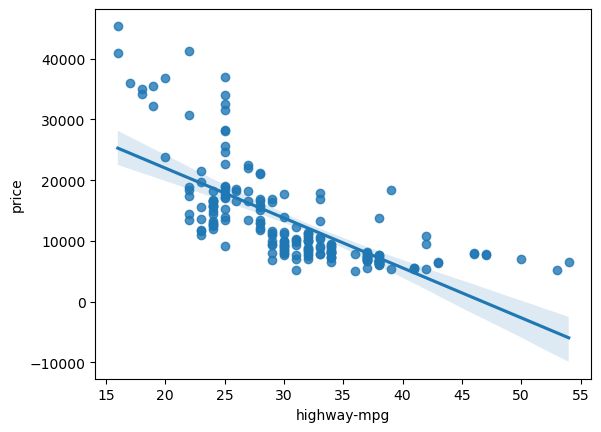

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt  

sns.regplot(x="highway-mpg", y="price", data=df)
plt.show()

In [30]:
# # outcome - negative linear relation
# As highway-mpg goes up, the price goes down: this indicates
# an inverse/negative relationship between these two variables. 
# Highway mpg could potentially be a predictor of price.
# df[['highway-mpg', 'price']].corr()
df[['highway-mpg', 'price']].corr() 

,highway-mpg,price
highway-mpg,1.000000,-0.704692
price,-0.704692,1.000000


In [31]:
# outcome
# correlation between 'highway-mpg' and 'price' is approximately -0.704.

In [32]:
#Data standardization is also a term for a 
#particular type of data normalization where you subtract 
#the mean and divide by the standard deviation

# transforming data into a common format, allowing the researcher 
#to make the meaningful comparison.

# Convert mpg to L/100km by mathematical operation (235 divided by mpg)
# df["city-mpg"] = 235/df["city-mpg"]
# rename column name from "city-mpg" to "city-L/100km"
#df.rename(columns={'city-mpg':'city-L/100km'}, inplace=True)
# This is data transformation

# transform mpg to L/100km in the column of "highway-mpg" 
#and change the name of column to "highway-L/100km".
# transform mpg to L/100km by mathematical operation (235 divided by mpg)
# df["highway-mpg"] = 235/df["highway-mpg"]
# rename column name from "highway-mpg" to "highway-L/100km"
# df.rename(columns={'highway-mpg':'highway-L/100km'}, inplace=True)

In [33]:
# Data Normalization
# transforming values of several variables into a similar range
# replace (original value) by (original value)/(maximum value)
# scaling the variable so the variable average is 0
# scaling the variable so the variance is 1
# scaling the variable so the variable values range from 0 to 1

df['length'] = df['length']/df['length'].max()
df['width'] = df['width']/df['width'].max()
df['height'] = df['height']/df['height'].max()

In [34]:
# scaled columns
df[["length","width","height"]].head()

,length,width,height
0,0.811148,0.890278,0.816054
1,0.811148,0.890278,0.816054
2,0.822681,0.909722,0.876254
3,0.848630,0.919444,0.908027
4,0.848630,0.922222,0.908027


In [35]:
# Binning
# transforming continuous numerical variables into 
# discrete categorical 'bins' for grouped analysis

#"horsepower" is a real valued variable ranging from 48 to 288 
# and it has 59 unique values.
# reading the price difference between cars with high horsepower, 
# medium horsepower, and little horsepower (3 types)

# rearrange them into three ‘bins' to simplify analysis

# Use 'cut' to segment the 'horsepower' column into 3 bins.

In [36]:
# converting into correct data type
df["horsepower"]=df["horsepower"].astype(int, copy=True)

In [37]:
#histogram of horsepower to see the distribution of horsepower.
# %matplotlib inline
# import matplotlib.pyplot as plt  
# Create histogram
# plt.hist(df["horsepower"])  # Use plt directly, not plt.pyplot

# set x/y labels and plot title
# plt.xlabel("horsepower")  # Use plt directly
# plt.ylabel("count")
# plt.title("horsepower bins")
# plt.show() 


In [38]:
# find three bins of equal size bandwidth using numpy
# linspace(start_value, end_value, numbers_generated)
# include min , max value of horsepower
# set start_value = min(df["horsepower"])
# set end_value = max(df["horsepower"])
# we want 3 bins of equal length, 
# hence need 4 dividers, so numbers_generated = 4.
# Build a bin array with a minimum value to a maximum value by using the 
# bandwidth calculated above. 
# The values will determine when one bin ends and another begins

In [39]:
%matplotlib inline
import matplotlib.pyplot as plt 
bins = np.linspace(min(df["horsepower"]), max(df["horsepower"]), 4)
bins
# set group name
group_names = ['Low', 'Medium', 'High']

In [40]:
#function "cut" to determine what each value of df['horsepower'] belongs to

df['horsepower-binned'] = pd.cut(df['horsepower'], bins, labels=group_names, include_lowest=True )
df[['horsepower','horsepower-binned']].head(20)


,horsepower,horsepower-binned
0,111,Low
1,111,Low
2,154,Medium
3,102,Low
4,115,Low
5,110,Low
6,110,Low
7,110,Low
8,140,Medium
9,101,Low


In [41]:
# see the number of vehicles in each bin
df["horsepower-binned"].value_counts()

horsepower-binned
Low       153
Medium     43
High        5
Name: count, dtype: int64

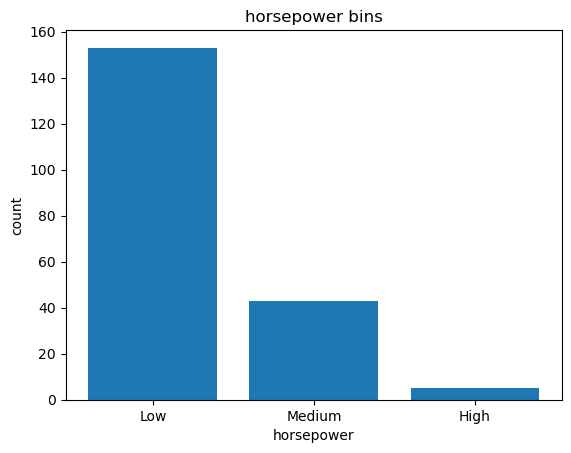

In [42]:
# plot distribution of each bin

%matplotlib inline
import matplotlib.pyplot as plt
plt.bar(group_names, df["horsepower-binned"].value_counts())

# set x/y labels and plot title
plt.xlabel("horsepower")  # Changed from plt.pyplot.xlabel
plt.ylabel("count")       # Changed from plt.pyplot.ylabel
plt.title("horsepower bins")  # Changed from plt.pyplot.title
plt.show()

In [43]:
# narrowed down the intervals from 59 to 3!

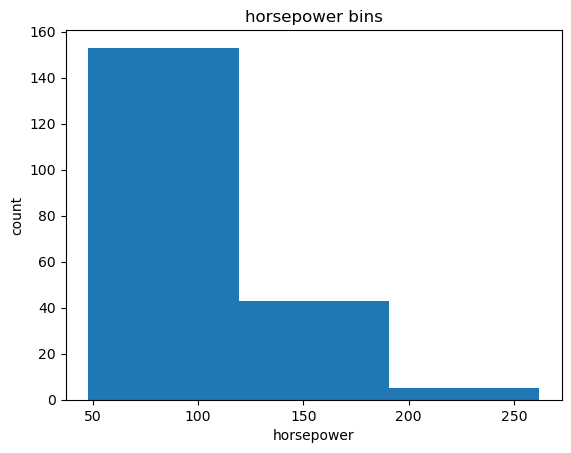

In [44]:
# Bin Visualisation - histogram to visualize the distribution of bins we created above.

%matplotlib inline
import matplotlib.pyplot as plt  

# historgram of attribute "horsepower" with bins = 3
plt.hist(df["horsepower"], bins = 3)  

# set x/y labels and plot title
plt.xlabel("horsepower")  # Use plt directly
plt.ylabel("count")       # Use plt directly
plt.title("horsepower bins")  # Use plt directly
plt.show()  

In [45]:
# indicator variable (or dummy variable) is a numerical variable used to label categories
# dummies as numbers themselves dont have inherent meaning
# "fuel-type" has two unique values: "gas" or "diesel"
# Regression doesnt understand words, just numbers
# To use these attributes in Regression, convert "fuel-type" to indicator variables
# get_dummies - assign numerical values to different categories of fuel type

In [46]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price', 'horsepower-binned'],
      dtype='object')

In [47]:
# indicator variables assigned to data frame dummy_variable_1
dummy_variable_1 = pd.get_dummies(df["fuel-type"]).astype(int)
dummy_variable_1.head()

,diesel,gas
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [48]:
# chaning the column names just for clarity
dummy_variable_1.rename(columns={'gas':'fuel-type-gas', 'diesel':'fuel-type-diesel'}, inplace=True)
dummy_variable_1.head()

,fuel-type-diesel,fuel-type-gas
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [49]:
# merge data frame "df" and "dummy_variable_1" 
df = pd.concat([df, dummy_variable_1], axis=1)

# drop original column "fuel-type" from "df"
df.drop("fuel-type", axis = 1, inplace=True)

In [50]:
# Last two colmns are now indicator variable representation 
# of the fuel-type variable. 
# They're all 0s and 1s now.

In [51]:
df['aspiration'].value_counts()

aspiration
std      165
turbo     36
Name: count, dtype: int64

In [52]:
# get indicator variables of aspiration and assign it to data 
# frame "dummy_variable_2"
dummy_variable_2 = pd.get_dummies(df['aspiration']).astype(int)

# change column names for clarity
dummy_variable_2.rename(columns={'std':'aspiration-std', 'turbo': 'aspiration-turbo'}, inplace=True)

# show first 5 instances of data frame "dummy_variable_1"
dummy_variable_2.head()

# merge the new dataframe to the original datafram
df = pd.concat([df, dummy_variable_2], axis=1)

# drop original column "aspiration" from "df"
df.drop('aspiration', axis = 1, inplace=True)


In [53]:
df.head()

,symboling,normalized-losses,make,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,horsepower,peak-rpm,city-mpg,highway-mpg,price,horsepower-binned,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
0,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,111,5000.0,21,27,13495.0,Low,0,1,1,0
1,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,111,5000.0,21,27,16500.0,Low,0,1,1,0
2,1,122,alfa-romero,two,hatchback,rwd,front,94.5,0.822681,0.909722,...,154,5000.0,19,26,16500.0,Medium,0,1,1,0
3,2,164,audi,four,sedan,fwd,front,99.8,0.848630,0.919444,...,102,5500.0,24,30,13950.0,Low,0,1,1,0
4,2,164,audi,four,sedan,4wd,front,99.4,0.848630,0.922222,...,115,5500.0,18,22,17450.0,Low,0,1,1,0


In [54]:
# when visualising individual variables,
# its important to understand what type 
# variabe we are dealing with
# print(df.dtypes)  
# run line above to see data types.

In [55]:
# data type of peak-rpm
df['peak-rpm'].dtypes

dtype('float64')

In [56]:
# the correlation between variables of type "int64" or "float64" using the method "corr":
# Select only numeric columns for correlation
# daigonal elements are always 1.
numeric_df = df.select_dtypes(include=['float64', 'int64'])
numeric_df.corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008153,-0.182196,0.075810,0.279740,-0.035527,0.036233,-0.082391,-0.196735,0.196735,0.054615,-0.054615
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055045,-0.114713,0.217300,0.239543,-0.225016,-0.181877,0.133999,-0.101546,0.101546,0.006911,-0.006911
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158018,0.250313,0.371178,-0.360305,-0.470606,-0.543304,0.584642,0.307237,-0.307237,-0.256889,0.256889
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.123952,0.159733,0.579795,-0.285970,-0.665192,-0.698142,0.690628,0.211187,-0.211187,-0.230085,0.230085
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188822,0.189867,0.615056,-0.245800,-0.633531,-0.680635,0.751265,0.244356,-0.244356,-0.305732,0.305732
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.060663,0.259737,-0.087001,-0.309974,-0.049800,-0.104812,0.135486,0.281578,-0.281578,-0.090336,0.090336
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167438,0.156433,0.757981,-0.279361,-0.749543,-0.794889,0.834415,0.221046,-0.221046,-0.321955,0.321955
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.205928,0.028889,0.822668,-0.256733,-0.650546,-0.679571,0.872335,0.070779,-0.070779,-0.110040,0.110040
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566903,-0.267392,-0.582027,-0.591309,0.543155,0.054458,-0.054458,-0.227816,0.227816
stroke,-0.008153,0.055045,0.158018,0.123952,0.188822,-0.060663,0.167438,0.205928,-0.055390,1.000000,0.187871,0.098128,-0.063561,-0.033956,-0.034636,0.082269,0.241064,-0.241064,-0.218233,0.218233


In [57]:
# correlation between bore, stroke, compression-ratio, and horsepower
numeric_df = df[['bore', 'stroke', 'compression-ratio','horsepower']]
numeric_df.corr()

,bore,stroke,compression-ratio,horsepower
bore,1.000000,-0.055390,0.001263,0.566903
stroke,-0.055390,1.000000,0.187871,0.098128
compression-ratio,0.001263,0.187871,1.000000,-0.214489
horsepower,0.566903,0.098128,-0.214489,1.000000


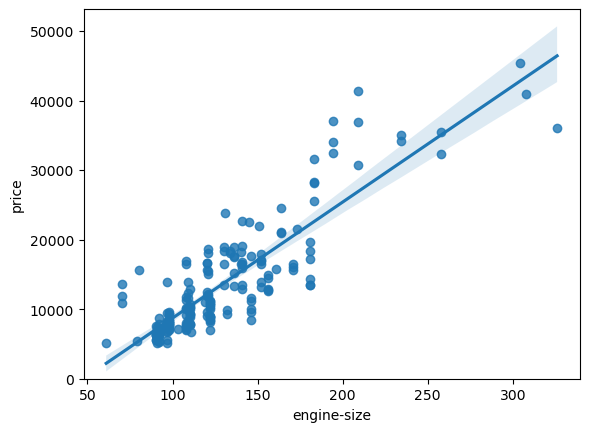

In [58]:
# Continuous numerical variables are variables that may contain any value within some range
# can be of type int and float.

# Engine size as potential predictor variable of price
sns.regplot(x="engine-size", y="price", data=df)
plt.ylim(0,)
plt.show()

# scatterplot of "engine-size" and "price".

In [59]:
# outcome - positive linear relation
# As the engine-size goes up, the price goes up.
# this indicates a positive direct correlation between these two variables. 
# Engine size seems like a pretty good predictor of price 
# since the regression line is almost a perfect diagonal line.

In [60]:
# correlation between 'engine-size' and 'price' 
# and see that it's approximately 0.877.
df[["engine-size", "price"]].corr()

,engine-size,price
engine-size,1.000000,0.872335
price,0.872335,1.000000


In [61]:
# Checking if "peak-rpm" is a predictor variable of "price"

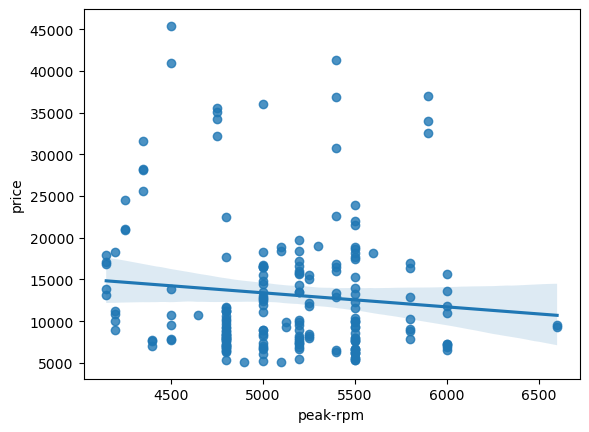

In [62]:
sns.regplot(x="peak-rpm", y="price", data=df)
plt.show()

In [63]:
# outcome - weak linear relation
# the regression line is close to horizontal
# peak-rpm is not a good predictor of price.
# data points are very scattered and far from the fitted line, 
# showing lots of variability
# not a reliable variable


In [64]:
# correlation between peak-rpm and price is approx -0.1016
df[['peak-rpm','price']].corr()

,peak-rpm,price
peak-rpm,1.000000,-0.101616
price,-0.101616,1.000000


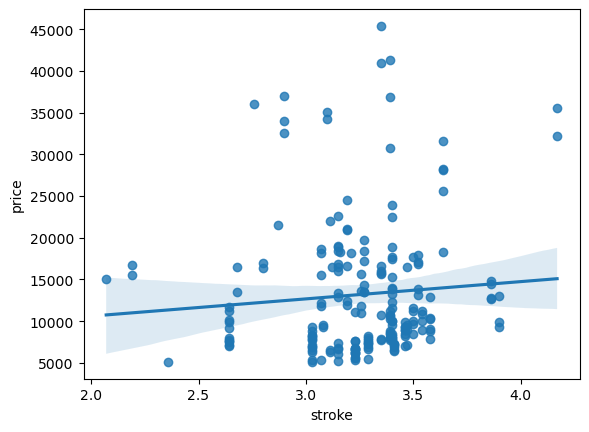

In [65]:
# relation between stroke and price

sns.regplot(x="stroke", y="price", data=df)
plt.show()

In [66]:
# outcome - weak linear relation

In [67]:
# correlation between stroke and price is approx 0.08
df[['stroke','price']].corr()

,stroke,price
stroke,1.000000,0.082269
price,0.082269,1.000000


In [68]:
# Categorical variables
# describe a 'characteristic' of a data unit, 
# are selected from a small group of categories. 
# can have the type "object" or "int64".
# visualize categorical variables by using boxplots.

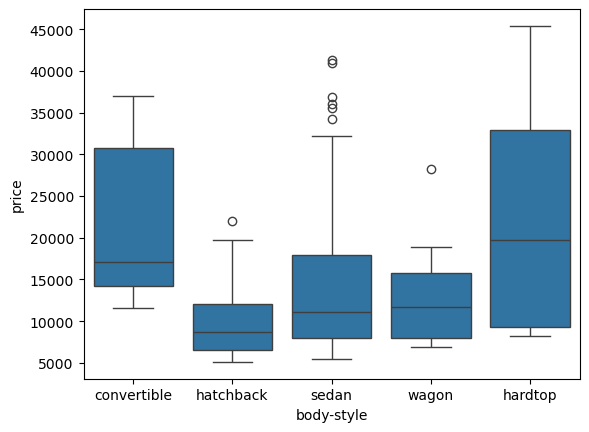

In [69]:
# relation between body-style and price
sns.boxplot(x="body-style", y="price", data=df)
plt.show()

In [70]:
#outcome - Not a good predictor of price
# distribution of price between different 
# body-style categories have a significant overlap

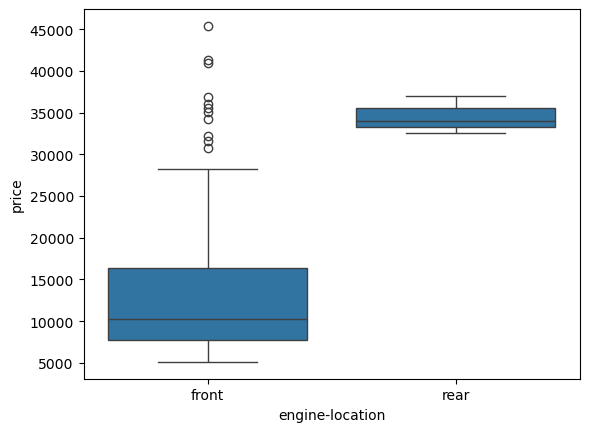

In [71]:
# relation between engine-location and price
sns.boxplot(x="engine-location", y="price", data=df)
plt.show()

In [72]:
# outcome - engine-location a good predictor of price
# distribution of price between the two engine-location categories
# i.e. front and rear are distinct enough

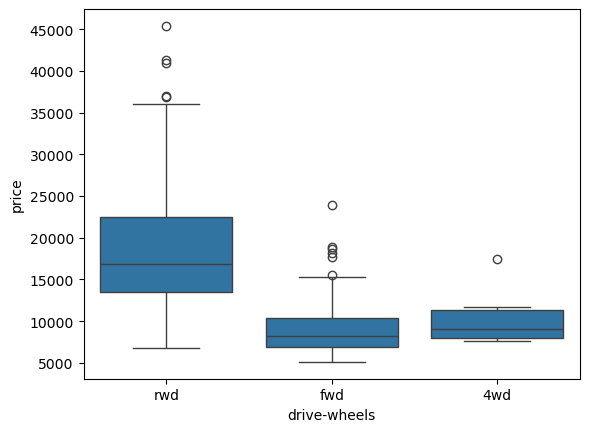

In [73]:
# relation between drive-wheels and price
sns.boxplot(x="drive-wheels", y="price", data=df)
plt.show()

In [74]:
#outcome - good predictor 
# distribution of price between the different
# drive-wheels categories differs

In [75]:
# Descriptive statistical analysis
# describe function automatically computes 
# basic statistics for all continuous variables
# it will show
# the count of that variable
# the mean
# the standard deviation (std)
# the minimum value
# the IQR (Interquartile Range: 25%, 50% and 75%)
# the maximum valuethe count of that variable

In [76]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,0.899108,2555.666667,126.875622,3.330692,3.256874,10.164279,103.402985,5117.665368,25.179104,30.686567,13207.129353,0.099502,0.900498,0.820896,0.179104
std,1.254802,31.99625,6.066366,0.059213,0.029187,0.040933,517.296727,41.546834,0.268072,0.316048,4.004965,37.365650,478.113805,6.423220,6.815150,7947.066342,0.300083,0.300083,0.384397,0.384397
min,-2.000000,65.00000,86.600000,0.678039,0.837500,0.799331,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,101.00000,94.500000,0.801538,0.890278,0.869565,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,0.000000,1.000000,1.000000,0.000000
50%,1.000000,122.00000,97.000000,0.832292,0.909722,0.904682,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,0.000000,1.000000,1.000000,0.000000
75%,2.000000,137.00000,102.400000,0.881788,0.925000,0.928094,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,0.000000,1.000000,1.000000,0.000000
max,3.000000,256.00000,120.900000,1.000000,1.000000,1.000000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,1.000000,1.000000,1.000000,1.000000


In [77]:
# default setting of "describe" skips variables of type object
# to describe object type
df.describe(include=['object'])

,make,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
count,201,201,201,201,201,201,201,201
unique,22,2,5,3,2,6,7,8
top,toyota,four,sedan,fwd,front,ohc,four,mpfi
freq,32,115,94,118,198,145,157,92


In [78]:
# Value counts
# how many units of each characteristic/variable we have
# NOTE - value_counts" only works on pandas series, not pandas dataframes
# means only one df[''] and not double df[['']]
df['drive-wheels'].value_counts()

drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

In [79]:
# convert the series to a dataframe 
df['drive-wheels'].value_counts().to_frame()

,count
drive-wheels,
fwd,118
rwd,75
4wd,8


In [80]:
# save the results to the dataframe "drive_wheels_counts"
# rename the column 'drive-wheels' to 'value_counts'
drive_wheels_counts = df['drive-wheels'].value_counts().to_frame()
drive_wheels_counts.reset_index(inplace=True)
drive_wheels_counts=drive_wheels_counts.rename(columns={'drive-wheels': 'value_counts'})
drive_wheels_counts

,value_counts,count
0,fwd,118
1,rwd,75
2,4wd,8


In [81]:
# rename the index to 'drive-wheels':
drive_wheels_counts.index.name = 'drive-wheels'
drive_wheels_counts

,value_counts,count
drive-wheels,,
0,fwd,118
1,rwd,75
2,4wd,8


In [82]:
# repeating the process for engine-location-
# engine-location as variable
engine_loc_counts = df['engine-location'].value_counts().to_frame()
engine_loc_counts.rename(columns={'engine-location': 'value_counts'}, inplace=True)
engine_loc_counts.index.name = 'engine-location'
engine_loc_counts.head(10)

,count
engine-location,
front,198
rear,3


In [83]:
# Outcome -  engine location would not be a good predictor variable for the price
#  we only have three cars with a rear engine and 198 
# with an engine in the front 
# result is skewed
# not able to draw conclusiosn

In [84]:
# group by - groups data by different categories
df['drive-wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [85]:
# 3 different categories of drive wheels
#  which type of drive wheel is most valuable on an average
#  select the columns 'drive-wheels', 'body-style' and 'price', 
# then assign it to the variable "df_group_one"
# then calculate the average price for each of the different categories of data

In [86]:
df_group_one = df[['drive-wheels','body-style','price']]
# grouping results
df_grouped = df_group_one.groupby(['drive-wheels'], as_index=False).agg({'price': 'mean'})
df_grouped

,drive-wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19757.613333


In [87]:
# outcome
# rear-wheel drive vehicles are, on average, the most expensive
# 4-wheel and front-wheel are approx same in price 

In [88]:
# group by multiple variables
df_gptest = df[['drive-wheels','body-style','price']]
grouped_test1 = df_gptest.groupby(['drive-wheels','body-style'],as_index=False).mean()
grouped_test1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


In [89]:
# convert the dataframe to a pivot table 
# using the method "pivot" to create 
# a pivot table from the groups.
# drive wheels as row
# body style as column

In [90]:
grouped_pivot = grouped_test1.pivot(index='drive-wheels',columns='body-style')
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

In [91]:
grouped_pivot = grouped_pivot.fillna(0) #fill missing values with 0
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

In [92]:
# "groupby" function to find the average 
# "price" of each car based on "body-style".
# grouping results
df_gptest2 = df[['body-style','price']]
grouped_test_bodystyle = df_gptest2.groupby(['body-style'],as_index= False).mean()
grouped_test_bodystyle

,body-style,price
0,convertible,21890.500000
1,hardtop,22208.500000
2,hatchback,9957.441176
3,sedan,14459.755319
4,wagon,12371.960000


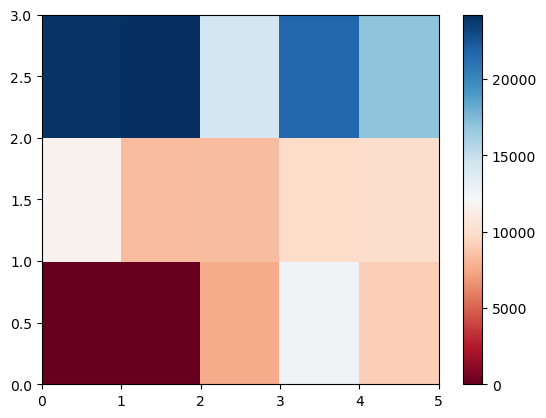

In [93]:
# heat map to visualize the relationship between Body Style vs Price.
plt.pcolor(grouped_pivot, cmap='RdBu')
plt.colorbar()
plt.show()

In [94]:
# outcome- plots the target variable (price) proportional to 
# colour with respect to the variables 'drive-wheel' and 'body-style' 
# on the vertical and horizontal axis, respectively.
# This allows us to visualize how the price is 
# related to 'drive-wheel' and 'body-style'.

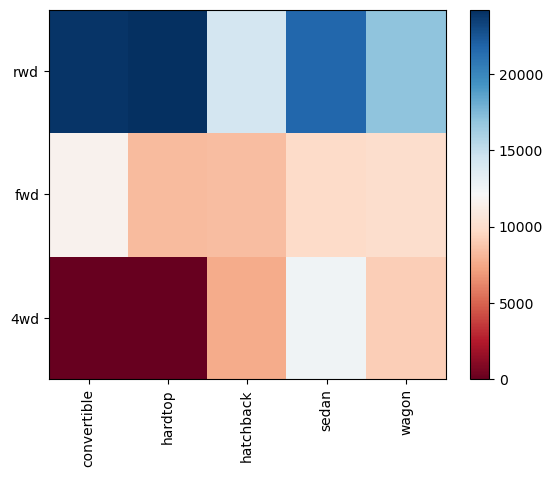

In [95]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

#label names
row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

#move ticks and labels to the center
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

#rotate label if too long
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

In [96]:
# correlation and causation
# Correlation: a measure of the extent of interdependence between variables.
# Causation: the relationship between cause and effect between two variables.

In [97]:
# The Pearson Correlation measures the 
# linear dependence between two variables X and Y.
# The resulting coefficient is a value between -1 and 1 inclusive, where:
# 1: Perfect positive linear correlation.
# 0: No linear correlation, the two variables most likely do not affect each other.
#-1: Perfect negative linear correlation.

In [98]:
# Pearson Correlation is the default method of the function "corr"
df.select_dtypes(include=['number']).corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008153,-0.182196,0.075810,0.279740,-0.035527,0.036233,-0.082391,-0.196735,0.196735,0.054615,-0.054615
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055045,-0.114713,0.217300,0.239543,-0.225016,-0.181877,0.133999,-0.101546,0.101546,0.006911,-0.006911
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158018,0.250313,0.371178,-0.360305,-0.470606,-0.543304,0.584642,0.307237,-0.307237,-0.256889,0.256889
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.123952,0.159733,0.579795,-0.285970,-0.665192,-0.698142,0.690628,0.211187,-0.211187,-0.230085,0.230085
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188822,0.189867,0.615056,-0.245800,-0.633531,-0.680635,0.751265,0.244356,-0.244356,-0.305732,0.305732
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.060663,0.259737,-0.087001,-0.309974,-0.049800,-0.104812,0.135486,0.281578,-0.281578,-0.090336,0.090336
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167438,0.156433,0.757981,-0.279361,-0.749543,-0.794889,0.834415,0.221046,-0.221046,-0.321955,0.321955
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.205928,0.028889,0.822668,-0.256733,-0.650546,-0.679571,0.872335,0.070779,-0.070779,-0.110040,0.110040
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566903,-0.267392,-0.582027,-0.591309,0.543155,0.054458,-0.054458,-0.227816,0.227816
stroke,-0.008153,0.055045,0.158018,0.123952,0.188822,-0.060663,0.167438,0.205928,-0.055390,1.000000,0.187871,0.098128,-0.063561,-0.033956,-0.034636,0.082269,0.241064,-0.241064,-0.218233,0.218233


In [99]:
# The P-value is the probability value that the correlation 
# between these two variables is statistically significant. 
# Normally, we choose a significance level of 0.05, which 
# means that we are 95% confident that the correlation 
# between the variables is significant.

In [100]:
# By convention when-:
# p-value < 0.001 - strong evidence that the correlation is significant.
# p-value < 0.05 -  moderate evidence that the correlation is significant.
# p-value < 0.1  -  weak evidence that the correlation is significant
# p-value > 0.1  -  there is no evidence that the correlation is significant.

In [101]:
from scipy import stats

In [102]:
#  Pearson Correlation Coefficient and P-value of 'wheel-base' and 'price'.

In [103]:
pearson_coef, p_value = stats.pearsonr(df['wheel-base'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)  

The Pearson Correlation Coefficient is 0.5846418222655081  with a P-value of P = 8.076488270732885e-20


In [104]:
# conclusion - the p value<0.001 suggests strong 
# evidence for significant correlation 
# However, PCC =0.58 represents not a strong linear relation.

In [105]:
# PCC and P-value of horsepower and price
pearson_coef, p_value = stats.pearsonr(df['horsepower'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.8096068016571054  with a P-value of P =  6.273536270650351e-48


In [106]:
# conclusion - the p value<0.001 suggests strong 
# evidence for significant correlation 
# PCC =0.809 represents a strong linear relation.

In [107]:
# PCC and P-value of length and price
pearson_coef, p_value = stats.pearsonr(df['length'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.6906283804483642  with a P-value of P =  8.016477466158868e-30


In [108]:
# conclusion - the p value<0.001 suggests strong 
# evidence for significant correlation 
# PCC =0.690 represents moderately strong linear relation.

In [109]:
# PCC and P-value of width and price
pearson_coef, p_value = stats.pearsonr(df['width'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.7512653440522673  with a P-value of P =  9.20033551048206e-38


In [110]:
# conclusion - the p value<0.001 suggests strong 
# evidence for significant correlation 
# PCC =0.751 represents strong linear relation.

In [111]:
# PCC and P-value of curb-weight and price
pearson_coef, p_value = stats.pearsonr(df['curb-weight'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.8344145257702845  with a P-value of P =  2.189577238893965e-53


In [112]:
# conclusion - the p value<0.001 suggests strong 
# evidence for significant correlation 
# PCC =0.8344 represents strong linear relation.

In [113]:
# PCC and P-value of engine-size and price
pearson_coef, p_value = stats.pearsonr(df['engine-size'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value) 

The Pearson Correlation Coefficient is 0.8723351674455185  with a P-value of P =  9.265491622198793e-64


In [114]:
# conclusion - the p value<0.001 suggests strong 
# evidence for significant correlation 
# PCC =0.87233 represents strong linear relation.

In [115]:
#  Model Development helps predict future observations from the data we have
#  helps understand the exact relationship between different variables and 
#  how these variables are used to predict the result 

In [116]:
# Simple Linear Regression
# help us understand the relationship between two variables
# predictor/independent variable (X) and 
# response/dependent variable (that we want to predict)(Y)
# Result of LR is a linear function that predicts the response/dependent variable 
# as a function of independent variable.

In [117]:
# Simple LR - Y=a+bX where 
# a - intercept i.e. value of Y for X=0
# b - slope i.e. value with which Y changes when X increases by 1

In [118]:
from sklearn.linear_model import LinearRegression

In [119]:
# create LR object
lm = LinearRegression()
lm

LinearRegression()

In [120]:
# how highway-mpg can help us predict car price
# highway-mmpg is the predictor
# price is the dependent
X = df[['highway-mpg']]
Y = df['price']

In [121]:
# linear modal
lm.fit(X,Y)

LinearRegression()

In [122]:
# output a prediction
Yhat=lm.predict(X)
Yhat[0:5] 

array([16236.50464347, 16236.50464347, 17058.23802179, 13771.3045085 ,
       20345.17153508])

In [123]:
# value of intercept a
lm.intercept_

np.float64(38423.305858157386)

In [124]:
# value of slope b
lm.coef_

array([-821.73337832])

In [125]:
# price = 38423.305-821(highway-mpg)

In [126]:
# create LR lm1
lm1 = LinearRegression()
lm1
# engine-size and price
X = df[['engine-size']]
Y = df['price']
# fit the modal
lm1.fit(X,Y)
# output a prediction
Yhat=lm1.predict(X)
Yhat[0:5] 

array([13728.4631336 , 13728.4631336 , 17399.38347881, 10224.40280408,
       14729.62322775])

In [127]:
# intercept a
lm1.intercept_

np.float64(-7963.338906281049)

In [128]:
# slope b
lm1.coef_

array([166.86001569])

In [129]:
# price = -7963.33+166(engine-size)
Price=-7963.34 + 166.86*df['engine-size']

In [130]:
# Multiple Linear Regression
# used to explain the relationship between one continuous response (dependent) variable 
# and two or more predictor (independent) variables used to explain the relationship 
# between one continuous response (dependent) variable and two or more predictor (independent) variable
# Y = a + b1X1 + b2X2 + b3X3 + b4X4

In [131]:
# Multiple Regression
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
# fit the linear model using four variables
lm.fit(Z, df['price'])

LinearRegression()

In [132]:
# value of intercept
lm.intercept_

np.float64(-15811.863767729232)

In [133]:
# value of slope
lm.coef_

array([53.53022809,  4.70805253, 81.51280006, 36.1593925 ])

In [134]:
# price = -15811.863+53.530(horsepower )+4.7080(curb-weight)
# +81.51(engine-size)+36.159(highway-mpg)

In [135]:
# Multiple Regression
#Z = df[['normalized-losses', 'highway-mpg']]
# fit the linear model using four variables
#lm1.fit(Z, df['price'])

In [136]:
# intercept a
#lm1.intercept_

In [137]:
# slope b
lm1.coef_

array([166.86001569])

In [138]:
# price = 38201.31 + 1.49789['normalized-losses']-820.4['highway-mpg']

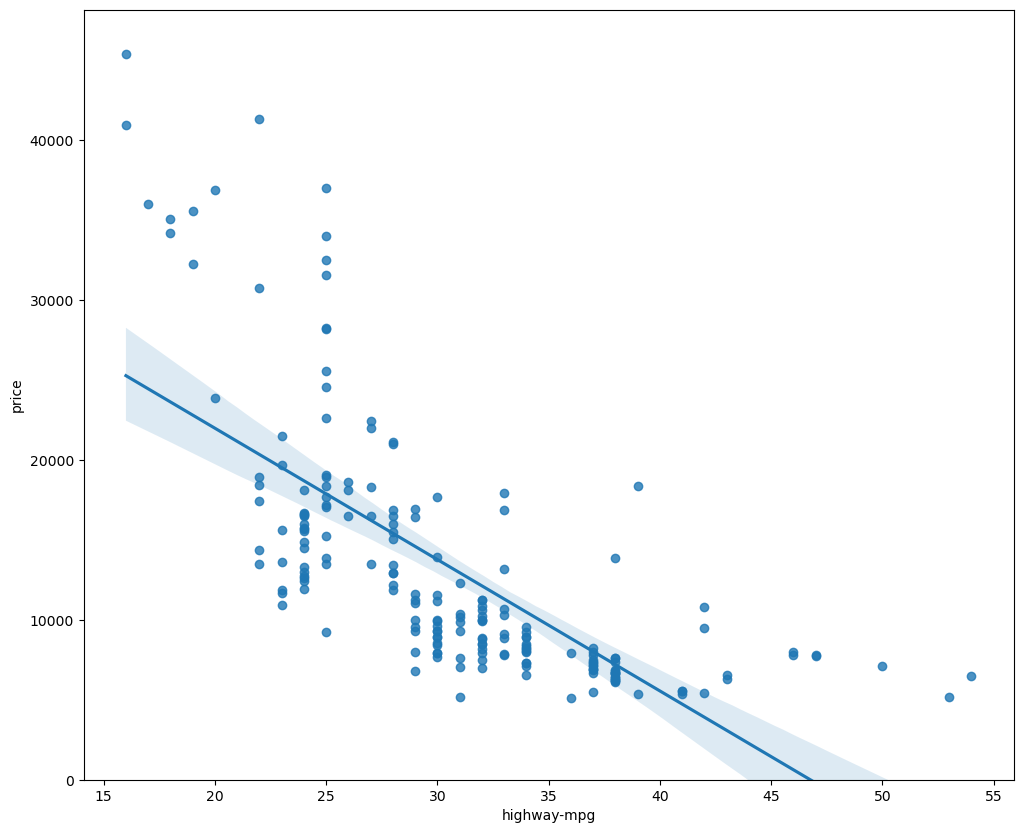

In [139]:
# visualize highway-mpg as potential predictor variable of price:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x="highway-mpg", y="price", data=df)
plt.ylim(0,)
plt.show()

In [140]:
# conclusion 
# price is negatively correlated to highway-mpg 
# since the regression slope is negative.
# pay attention to how scattered the data points are around the regression line
# as it gives good indication of the variance of the data 
# and whether a linear model would be the best fit or not.
# If data is too far off from the line, 
# this linear model might not be the best model for this data.

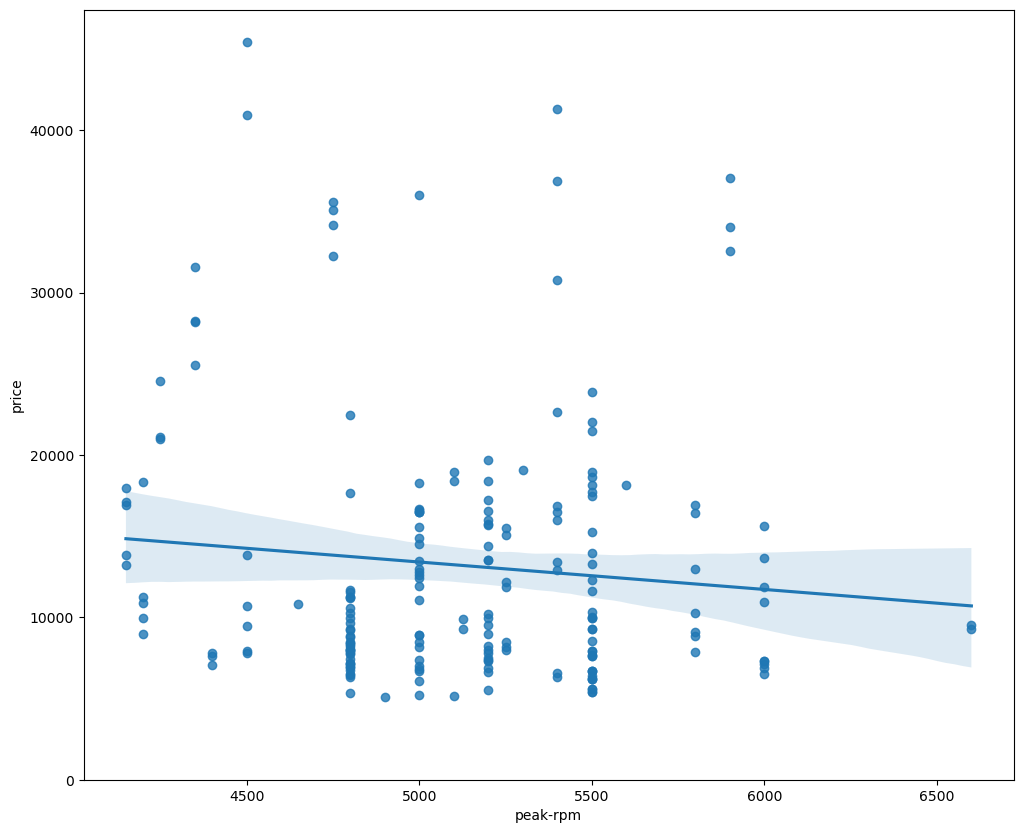

In [141]:
# Regression plot of peak-rpm and price
plt.figure(figsize=(width, height))
sns.regplot(x="peak-rpm", y="price", data=df)
plt.ylim(0,)
plt.show()

In [142]:
# Comparison
#  points for "highway-mpg" are much closer to the generated line and, on average, decrease
# points for "peak-rpm" have more spread around the predicted line and it is much harder 
# to determine if the points are decreasing or increasing as the "peak-rpm" increases.

In [143]:
df[['price','highway-mpg','peak-rpm']].corr()

,price,highway-mpg,peak-rpm
price,1.000000,-0.704692,-0.101616
highway-mpg,-0.704692,1.000000,-0.058598
peak-rpm,-0.101616,-0.058598,1.000000


In [144]:
# Residual Plot -  visualize the variance of the data 
# Residual = difference between the observed value (y) 
# and the predicted value (Y)
# Its the distance from the data point to the fitted regression line. 

# graph that shows the residuals on the vertical y-axis
# and the independent variable on the horizontal x-axis

# look at the spread of the residuals

# If the points in a residual plot are randomly spread out around the x-axis, 
# then a linear model is appropriate for the data.

# Randomly spread out residuals means that the variance is constant, 
# and thus the linear model is a good fit for this data.

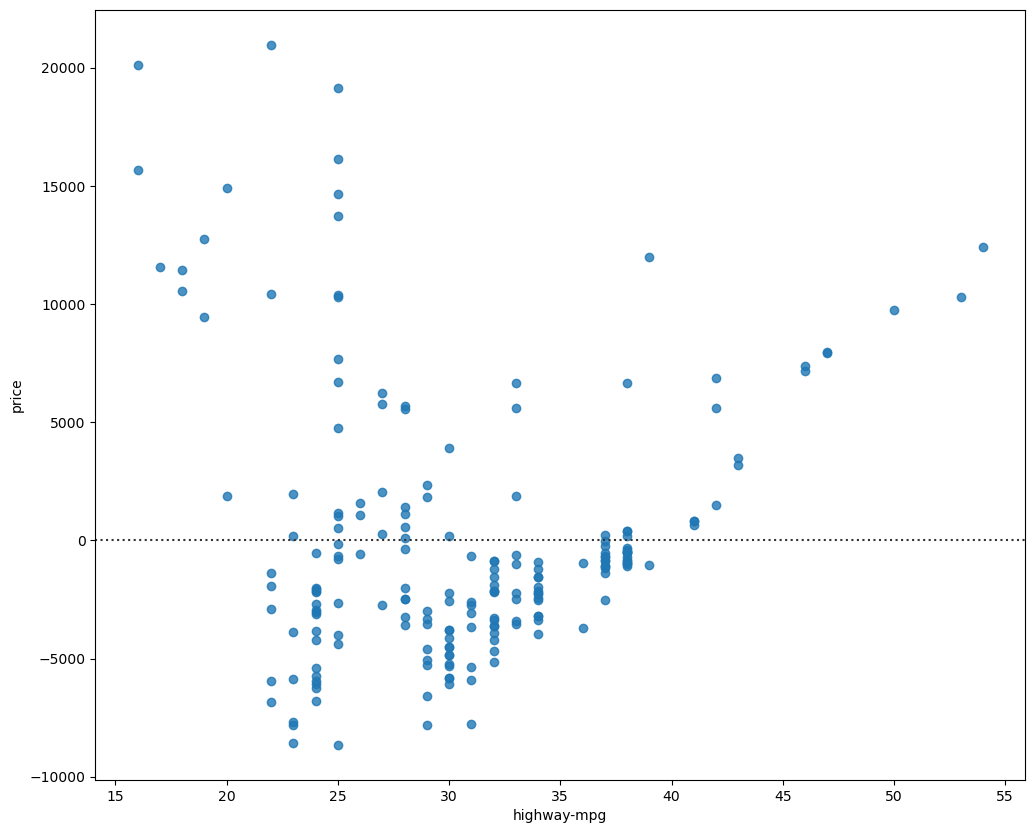

In [145]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.residplot(x=df['highway-mpg'], y=df['price'])
plt.show()

In [146]:
# Conclusion
# residuals are not randomly spread around the x-axis, 
# leading us to believe that maybe a non-linear model 
# is more appropriate for this data

In [147]:
# Multiple Linear Reression plot
# distribution of the fitted values that result from the model 
# and compare it to the distribution of the actual values.

C:\Users\USER\AppData\Local\Temp\ipykernel_18484\3606426225.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
C:\Users\USER\AppData\Local\Temp\ipykernel_18484\3606426225.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

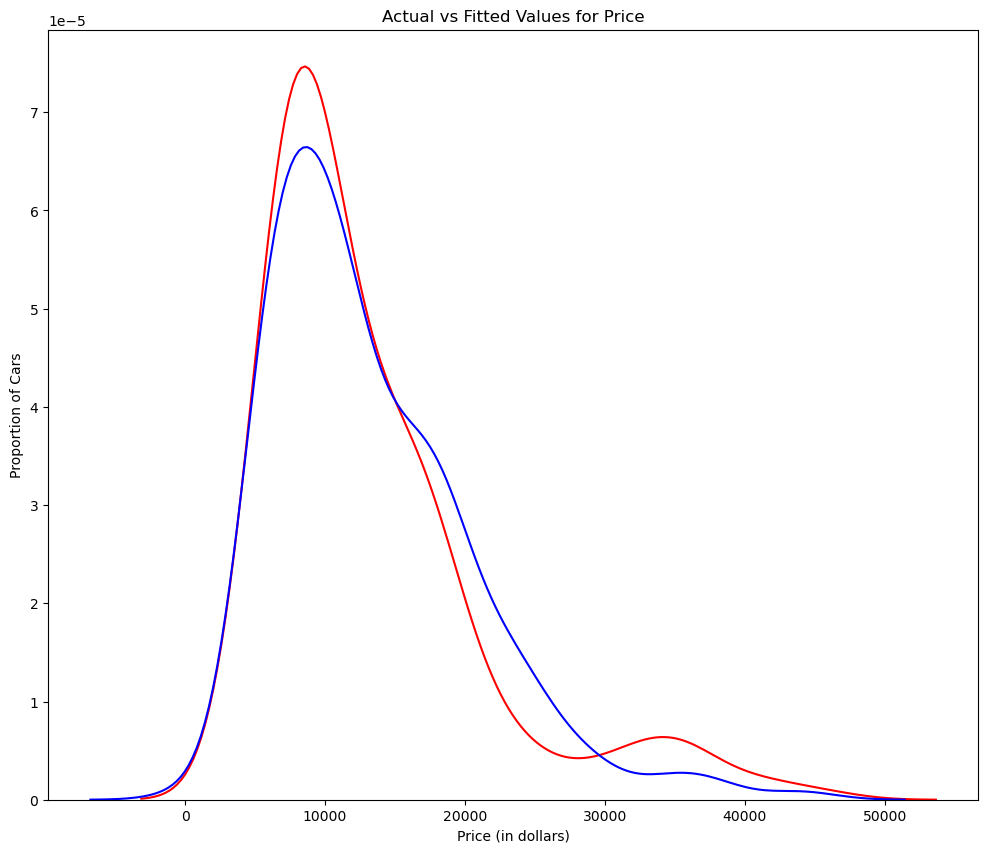

In [148]:
Y_hat = lm.predict(Z)
plt.figure(figsize=(width, height))


ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_hat, hist=False, color="b", label="Fitted Values" , ax=ax1)


plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()

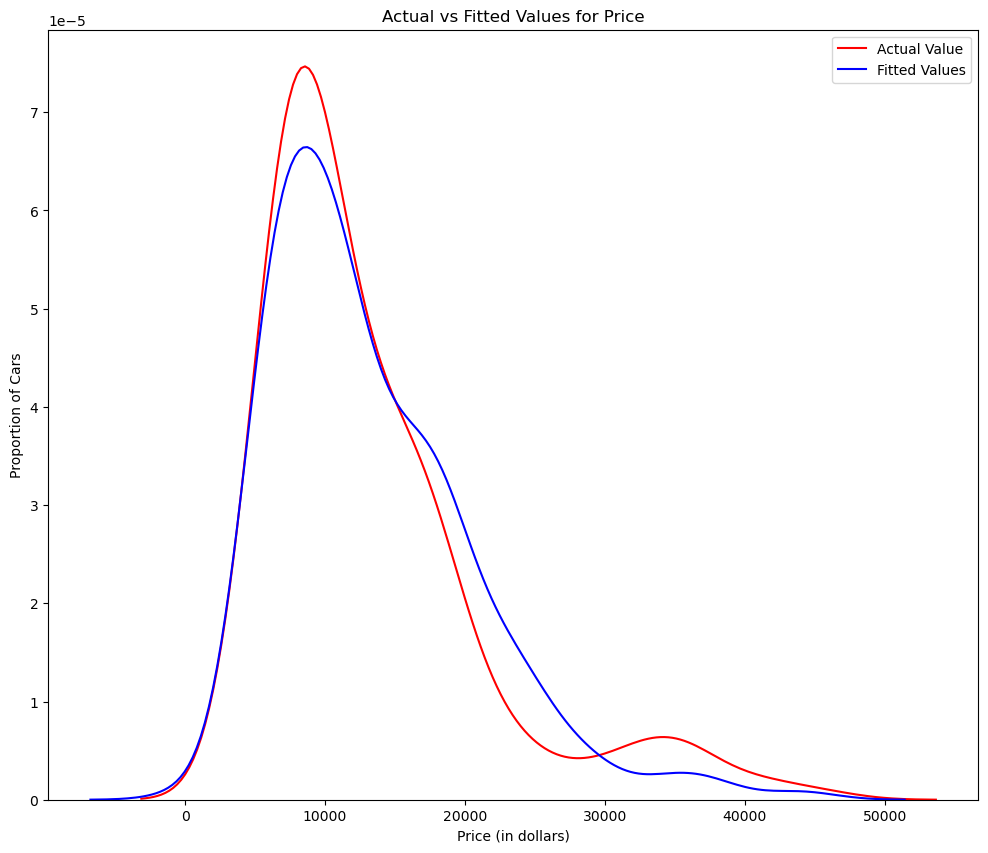

In [149]:
# Assuming your DataFrame has a different column name for price
# First, check what columns are available in your DataFrame
# print(df.columns)

# Then use the correct column name (this example assumes it's 'price' lowercase)
Y_hat = lm.predict(Z)
plt.figure(figsize=(width, height))

# Using kdeplot instead of distplot (since we're working with axes-level plots)
ax1 = plt.gca()  # Get current axes
sns.kdeplot(df['price'], color="r", label="Actual Value", ax=ax1)  # Changed 'Price' to 'price'
sns.kdeplot(Y_hat, color="b", label="Fitted Values", ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')
plt.legend()  # Add legend explicitly since we're using kdeplot

plt.show()

In [150]:
#  fitted values are reasonably close to the actual values since the two distributions overlap a bit

In [151]:
# Polynomial Regression 
# particular case of the general linear regression model or multiple linear regression models
# non-linear relationships by squaring or setting higher-order terms of the predictor variables

In [152]:
# quadratic - b1+b2x+b3x^2
# cubic - b1+b2x+b3x^2+b4x^3
# higher - b1+b2x+b3x^2+b4x^3+...

In [153]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(15, 55, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Cars')
    plt.show()
    plt.close()

In [154]:
x = df['highway-mpg']
y = df['price']

In [155]:
# Here we use a polynomial of the 3rd order (cubic) 
f = np.polyfit(x, y, 3)
p = np.poly1d(f)
print(p)

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


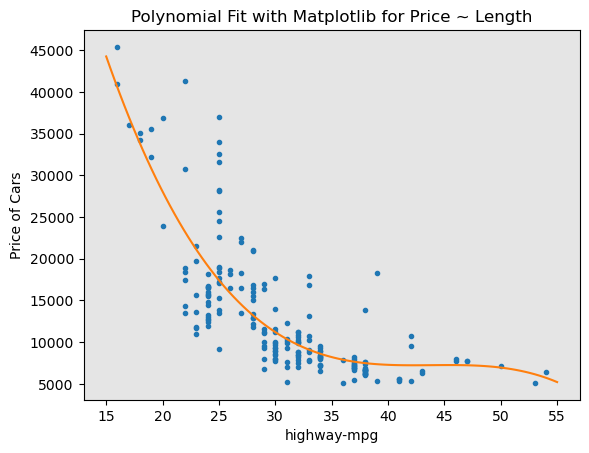

In [156]:
PlotPolly(p, x, y, 'highway-mpg')

In [157]:
# Conclusion
# polynomial model performs better than the linear model. 
# This is because the generated polynomial function "hits" more of the data points.

In [158]:
np.polyfit(x, y, 3)

array([-1.55663829e+00,  2.04754306e+02, -8.96543312e+03,  1.37923594e+05])

            11             10             9           8         7
-1.243e-08 x  + 4.722e-06 x  - 0.0008028 x + 0.08056 x - 5.297 x
          6        5             4             3             2
 + 239.5 x - 7588 x + 1.684e+05 x - 2.565e+06 x + 2.551e+07 x - 1.491e+08 x + 3.879e+08


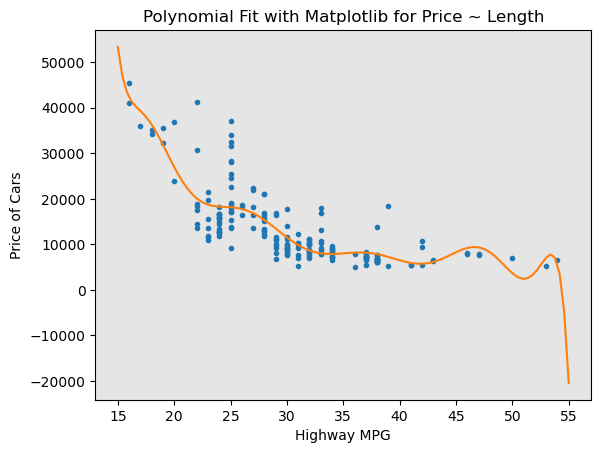

In [159]:
# Here we use a polynomial of the 11rd order (cubic) 
f1 = np.polyfit(x, y, 11)
p1 = np.poly1d(f1)
print(p1)
PlotPolly(p1,x,y, 'Highway MPG')

In [160]:
from sklearn.preprocessing import PolynomialFeatures

In [161]:
pr=PolynomialFeatures(degree=2)
pr

PolynomialFeatures()

In [162]:
Z_pr=pr.fit_transform(Z)

In [163]:
# orginal
Z.shape

(201, 4)

In [164]:
# after transformation
Z_pr.shape

(201, 15)

In [165]:
# Pipeline - simplify the steps of processing the data
# module Pipeline to create a pipeline
# StandardScaler as a step in our pipeline

In [166]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [167]:
#  create the pipeline by creating a list of tuples including the name of the model 
#  or estimator and its corresponding constructor
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]

In [168]:
#  input the list as an argument to the pipeline constructor
pipe=Pipeline(Input)
pipe

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [169]:
# First, convert the data type Z to type float
# to avoid conversion warnings that may appear 
# as a result of StandardScaler taking float inputs.
# Then, normalize the data, perform a transform 
# and fit the model simultaneously.

In [170]:
Z = Z.astype(float)
pipe.fit(Z,y)

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [171]:
ypipe=pipe.predict(Z)
ypipe[0:4]

array([13102.93329646, 13102.93329646, 18226.43450275, 10391.09183955])

In [172]:
# Create a pipeline that standardizes the data, 
# then produce a prediction using a linear regression model
# using the features Z and target y.
Input=[('scale',StandardScaler()),('model',LinearRegression())]

pipe=Pipeline(Input)

pipe.fit(Z,y)

ypipe=pipe.predict(Z)
ypipe[0:10]

array([13699.07700462, 13699.07700462, 19052.71346719, 10620.61524404,
       15520.90025344, 13869.27463809, 15455.88834114, 15973.77411958,
       17612.7829335 , 10722.47987021])

In [173]:
# measures to determine the accuracy of the model:
# 1. R^2 / R-squared (coefficient of determination)
# 2. Mean Squared Error (MSE)
# r-squared - coefficient of determination, is a measure to indicate 
# how close the data is to the fitted regression line
# its value is percentage of variation of the 
# response variable (y) that is explained by a linear model
# mean squuared error - measures the average of the squares of errors.
# which is the difference between actual value (y) and the estimated value (ŷ)

In [174]:
# Simple Linear Regression
#highway_mpg_fit
lm.fit(X, Y)
# Find the R^2
print('The R-square is: ', lm.score(X, Y))

The R-square is:  0.7609686443622008


In [175]:
# can predict the output i.e., "yhat" using the predict method, 
# where X is the input variable
Yhat=lm.predict(X)
print('The output of the first four predicted value is: ', Yhat[0:4])

The output of the first four predicted value is:  [13728.4631336  13728.4631336  17399.38347881 10224.40280408]


In [176]:
#  import the function mean_squared_error from the module metrics
from sklearn.metrics import mean_squared_error

In [177]:
# compare the predicted results with actual results
mse = mean_squared_error(df['price'], Yhat)
print('The mean square error of price and predicted value is: ', mse)

The mean square error of price and predicted value is:  15021126.02517414


In [178]:
# Muultiple Linear Regression
# fit the model 
lm.fit(Z, df['price'])
# Find the R^2
print('The R-square is: ', lm.score(Z, df['price']))

The R-square is:  0.8093732522175299


In [179]:
# conclusion - ~80.896 % of the variation of price is explained
# by this multiple linear regression "multi_fit".

In [180]:
# produce a prediction
Y_predict_multifit = lm.predict(Z)
print('The mean square error of price and predicted value using multifit is: ', \
      mean_squared_error(df['price'], Y_predict_multifit))

The mean square error of price and predicted value using multifit is:  11979300.34981888


In [181]:
# polynomial fit
from sklearn.metrics import r2_score

In [182]:
r_squared = r2_score(y, p(x))
print('The R-square value is: ', r_squared)

The R-square value is:  0.674194666390652


In [183]:
mean_squared_error(df['price'], p(x))

20474146.426361218

In [184]:
# prediction and decision making
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline 

In [185]:
# create a new input
new_input=np.arange(1, 100, 1).reshape(-1, 1)

In [186]:
# fit the model
lm.fit(X, Y)
lm

LinearRegression()

In [187]:
# predict 
yhat=lm.predict(new_input)
yhat[0:5]

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([-7796.47889059, -7629.6188749 , -7462.75885921, -7295.89884352,
       -7129.03882782])

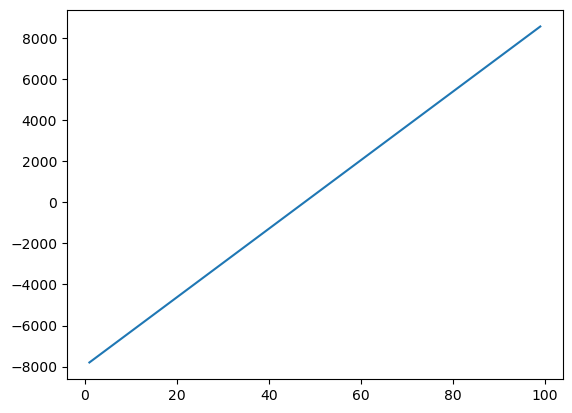

In [188]:
plt.plot(new_input, yhat)
plt.show()

In [189]:
#  a good R-squared value
#  the model with the higher R-squared value is a better fit for the data
#  a good MSE
#  the model with the smallest MSE value is a better fit for the data
# in this case MLR has the highest R-squared value and the least error. 